In [ ]:
# Clone of the LiCSBAS tutorial for use
# We used an active development version of LiCSBAS available at github.com/comet-licsar/licsbas 
# as ‘dev’ branch from the v1.2 release

# COMET InSAR Workshop 2023: LiCSBAS Tutorial

The aim of this tutorial is to understand and complete the processing steps of open-source LiCSBAS software required to prepare a time series analysis for Campi Flegrei using LiCSAR data from 2016-2021.  


This notebook is provided with default parameters using a subset of data to ensure that the practical session can be completed in the allotted time. The practical instructor will talk through the parameters and the operation of the notebook; however, you are not required to make edits for the notebook to run.

### please run the following cell first to load some necessary modules:  
(to run a cell, just click into it and press shift-Enter)  

#### Note: in case your notebook gets frozen/kernel disconnected, try clicking Kernel->Restart (rather than Refreshing page). If this runs ok, you may just rerun the following cell, and then skip back to the cell you were in before.

**cell \[ 00 \]** - this is a naming of a cell below:

In [118]:
from IPython.display import Image #as display
import os

os.environ['PATH']='/Users/rochelle/Documents/GitHub/LiCSBAS/bin:/Users/rochelle/Documents/GitHub/LiCSBAS/bin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/opt/anaconda3/envs/licsbas/bin:/opt/anaconda3/condabin'
os.environ['PYTHONPATH']='/Users/rochelle/Documents/GitHub/LiCSBAS/LiCSBAS_lib:/Users/rochelle/Documents/GitHub/LiCSBAS/LiCSBAS_lib:'

os.getcwd()


import warnings
warnings.filterwarnings('ignore')

# some extra functions
def display(png):
    if not os.path.exists(png):
        print('This png file does not exist, recheck please')
    else:
        return Image(png)

def printbold(instr='done'):
    print('\033[1m' + instr + '\033[0m')

# selected frame
frame = '078D_05435_131313'

# Once you identified the frame ID to process and confirmed that 
# the sufficient interferograms are available on the frame, 
# make a processing directory and change to the directory
framedir = os.path.join(os.environ['HOME'],frame)
try:
    os.mkdir(framedir)
except:
    pass

os.chdir(framedir)

if not os.path.exists('GEOCml2GACOS'):
    print('downloading the licsbas pre-prepared dataset, may take a while')    # the data are online here (but pre-downloaded by postBuild)
    os.system('wget https://gitlab.com/comet_licsar/licsbas/-/raw/50255b48440479c35f5ffe65bbbf93795af25f73/tutorial/022D_04826_121209_ml2gacosclip.7z')
    # or this one - a result of time series only:
    # os.system('wget https://gitlab.com/comet_licsar/licsbas/-/raw/50255b48440479c35f5ffe65bbbf93795af25f73/tutorial/022D_04826_121209_TS_result.7z')
    print('Extracting preprocessed data')
    os.system('7za x 022D_04826_121209_ml2gacosclip.7z >/dev/null 2>/dev/null')
    #os.system('7za x 022D_04826_121209_TS_result.7z >/dev/null 2>/dev/null')   # this is for the result of time series only

print('prerequisites loaded, thank you. Running in directory:')
print(os.getcwd())

printbold()

downloading the licsbas pre-prepared dataset, may take a while
Extracting preprocessed data
prerequisites loaded, thank you. Running in directory:
/Users/rochelle/078D_05435_131313
done


sh: wget: command not found


# LiCSBAS Tutorial

LiCSBAS is an open-source package in Python and bash to carry out InSAR time series analysis using LiCSAR products (i.e., unwrapped interferograms and coherence) which are freely available on the [COMET-LiCS web portal](https://comet.nerc.ac.uk/COMET-LiCS-portal/).



Users can easily derive the time series and velocity of the displacement if sufficient LiCSAR products are available in the area of interest. LiCSBAS also contains visualization tools to interactively display the time series of displacement to help investigation and interpretation of the results.  

## Documentation

The original LiCSBAS repository is [here](https://github.com/yumorishita/LiCSBAS). For more detailed information, see the [**wiki**](https://github.com/yumorishita/LiCSBAS/wiki) pages and [quick start](https://github.com/yumorishita/LiCSBAS/wiki/2_0_workflow#quick-start).  

This tutorial is run through Jupyter Notebook - see short [tutorial](https://www.dataquest.io/blog/jupyter-notebook-tutorial) if you are not familiar with this environment.

## LiCSBAS Workflow

<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/workflow.png" width=650>

# Module 0: Preparing the dataset

This tutorial will run on a preprocessed dataset (i.e. modules 0 are complete here) that is clipped in both time and space, and cover covers volcanic area of Campi Flegrei in Napoli region (Italy). The figure below shows GPS network measurements over the Napoli region, published in https://www.mdpi.com/2072-4292/13/14/2725. The Campi Flegrei caldera (in the middle) has been inflating since 2010s, a continuous uplift can be observed from the GPS station time series (middle plot).  

<img src="tutorial/campi_flegrei_gps.png" width="1000">

You may use the following module 0 steps to process another frame of your interest. **For the purposes of this tutorial, they are marked as skipped**.  


Note: you may identify LiCSAR frames covering your own area of interest (AOI) in your free time later. For this, you may just check the [COMET LiCSAR portal](https://comet.nerc.ac.uk/COMET-LiCS-portal/).  


## (skipping) Step 0-1: Download GeoTIFF from COMET-LiCS web portal


### LiCSBAS01_get_geotiff.py
This script downloads GeoTIFF files of unw (unwrapped interferogram) and cc (coherence) in the specified frame ID from COMET-LiCS web portal.  
The -f option is not necessary when the frame ID can be automatically identified from the name of the working directory.  
GACOS data can also be downloaded if available.  
Existing GeoTIFF files are not re-downloaded to save time, i.e., only the newly available data will be downloaded.  

**Note:** LiCSBAS is capable of running on any network of standard unwrapped interferograms if these exist in GEOC/YYYYMMDD_YYYYMMDD together with coherence (either in 0-1 or 0-255 range)

**cell \[ 01 \]**

In [306]:
# check the contents of the folder
frame = '078D_05435_131313'
# framedir = os.path.join(os.environ['HOME'],frame)
framedir = os.path.join(os.environ['HOME'],frame + "_noreunwrapping")
os.chdir(framedir)

! pwd
! ls

/Users/rochelle/078D_05435_131313_noreunwrapping
GACOS            GEOCml10         TS_GEOCml10GACOS
GEOC             GEOCml10GACOS    ifg_list.txt


In [3]:
import os
dir = os.path.join(os.environ['HOME'],"Downloads")
os.chdir(dir)
fig.savefig("frame_merge_map_UD.png")
os.chdir("idk move back to working directory??")
! pwd
! ls

/Users/rochelle/Downloads
023061020006.pdf
1720964426553410.png
2004107.pdf
2023474_ELEE08021.pdf
71D.meancoh.5km.48.tif
7z2407-mac
7z2407-mac.tar.xz
Aishite Aishite Aishite (Rock Version) (Main Camera).MTS
C290FF738ACDABAFC8E7AEFB39F52DB8.png
Cowgill, E. 2010.pdf
Discord.dmg
Fault Lines of Hindu Kush Himalayan (HKH) Region
Fault Lines of Hindu Kush Himalayan (HKH) Region.zip
Firefox 127.0.2.dmg
GitHubDesktop-x64.zip
IMG_1425.MOV
Kaguya_Mashup_change.mscz
Muse_Hub.dmg
OperaSetup.zip
ScienceDirect_files_12Jul2024_10-19-52.372
ScienceDirect_files_12Jul2024_10-19-52.372.zip
Seismic-20Processing-201-20--20Intro_2024.pdf
Seismogenic Fault and Building Damage of the 2023 Herat Earthquake Sequence Revelated by Radar Interferometry.pdf
Slab2_hin.xml
SpiderGraphMac
SpiderGraphMac.zip
Spyder_arm64.dmg
T_Love_Dramatic (1).mscz
Users:rochelle:Documents:Gi.textClipping
VSCode-darwin-universal.zip
Visual Studio Code.app
Zotero-6.0.37.dmg
a1483a27-ed5d-11ed-a05c-01aa75ed71a1.rdf
ahb_7_wmean2_05-Aug-2

In [110]:
! LiCSBAS01_get_geotiff.py -h
#e.g. LiCSBAS01_get_geotiff.py -f 167D_04884_131212 --get_gacos --n_para 1
printbold()


LiCSBAS01_get_geotiff.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS01_get_geotiff.py -h


Overview
This script downloads GeoTIFF files in the specified frame ID from COMET-LiCS web portal.
By default, unw (unwrapped interferogram) and cc (coherence) files are downloaded
The -f option is not necessary when the frame ID can be automatically identified from the name of the working directory.
GACOS data can also be downloaded if available. Existing GeoTIFF files are not re-downloaded to save time, i.e., only the newly available data will be downloaded.

Output files
 - GEOC/
   - yyyymmdd_yyyymmdd/
     - yyyymmdd_yyyymmdd.geo.unw.tif
     - yyyymmdd_yyyymmdd.geo.cc.tif
    [- yyyymmdd_yyyymmdd.geo.diff_pha.tif] (if --get_pha is used)
    [- yyyymmdd_yyyymmdd.geo.diff_unfiltered_pha.tif] (if --get_pha is used)
  [- *.geo.mli.tif (using just one first epoch)]
   - *.geo.E.tif
   - *.geo.N.tif
   - *.geo.U.tif
   - *.geo.hgt.tif
   - baselines
  

In [139]:
! LiCSBAS01_get_geotiff.py --get_pha -f 151D_05440_131313 –-get_gacos


LiCSBAS01_get_geotiff.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS01_get_geotiff.py --get_pha -f 151D_05440_131313 –get_GACOS

Frame ID is 151D_05440_131313

151D_05440_131313.geo.E.tif already exist. Skip download.
151D_05440_131313.geo.N.tif already exist. Skip download.
151D_05440_131313.geo.U.tif already exist. Skip download.
151D_05440_131313.geo.hgt.tif already exist. Skip download.

Download baselines
    baselines, 6.22KB, 1s, 6.22KB/s
Download network.png
    network.png, 496.21KB, 1s, 496.21KB/s
Download metadata.txt
    metadata.txt, 248.0B, 1s, 248.0B/s

151D_05440_131313.geo.mli.tif already exist. Skip.



Download geotiff of InSAR products
701 IFGs available from 20141016 to 20240520
Checking and downloading (4 parallel, may take time)...
unw data:
701 already downloaded
cc data:
701 already downloaded
diff_pha data:
699 already downloaded

Download diff_pha (4 parallel)...
    HTTPError for 20191201_20191213.geo.diff_pha.tif

## (skipping) Step 0-2: Convert and downsample

### LiCSBAS02_ml_prep.py
This script converts GeoTIFF files of unw and cc to float32 and uint8 format, respectively, for further time series analysis, and also downsamples (multilooks) data if specified.  
Existing files are not re-created to save time, i.e., only the newly available data will be processed.  

**Note:** LiCSAR team develops an updated way of unwrapping geotiffs with interferometric phase that would take advantage of multilooking. For this advanced functionality, you may want to check https://comet-licsar.github.io/licsar_proc/apidoc.html#licsar-unwrapping-module but note it is still in the stage of active development. The COMET LiCSAR team intends to include unwrapping in the next major release of LiCSBAS.

**cell \[ 02 \]**

In [ ]:
! LiCSBAS02_ml_prep.py -h
# e.g. LiCSBAS02_ml_prep.py -i GEOC -o GEOCml10 -n 10 --npara 1
printbold()

Starting
not loading RANSAC (optional experimental function)

LiCSBAS02_ml_prep.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS02_ml_prep.py -h


This script converts GeoTIFF files of unw and cc to float32 and uint8 format, respectively, for further time series analysis, and also downsamples (multilooks) data if specified. Existing files are not re-created to save time, i.e., only the newly available data will be processed.

Input & output files
Inputs:
 - GEOC/
   - yyyymmdd_yyyymmdd/
     - yyyymmdd_yyyymmdd.geo.unw.tif
     - yyyymmdd_yyyymmdd.geo.cc.tif
  [- *.geo.mli.tif]
  [- *.geo.hgt.tif]
  [- *.geo.[E|N|U].tif]
  [- baselines]
  [- metadata.txt]

Outputs in GEOCml*/ (downsampled if indicated):
 - yyyymmdd_yyyymmdd/
   - yyyymmdd_yyyymmdd.unw[.png] (float32)
   - yyyymmdd_yyyymmdd.cc (uint8)
 - baselines (may be dummy)
 - EQA.dem_par
 - slc.mli.par
 - slc.mli[.png] (if input exists)
 - hgt[.png] (if input exists)
 - [E|N|U].geo (if inp

In [307]:
! LiCSBAS02_ml_prep.py -i GEOC -n 10

Starting

LiCSBAS02_ml_prep.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS02_ml_prep.py -i GEOC -n 10

Create E.geo
/opt/anaconda3/envs/licsbas/lib/python3.12/site-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
  E.geo created

Create N.geo
  N.geo created

Create U.geo
  U.geo created

Create slc.mli
  slc.mli[.png] created

Create hgt
  hgt[.png] created

Create unw and cc
  808/1608 unw and cc already exist. Skip
  8 parallel processing...
    0/800th IFG...
   50/800th IFG...
  100/800th IFG...
  No 20170422_20170516.geo.unw.tif found. Skip
  No 20170422_20170528.geo.unw.tif found. Skip
  150/800th IFG...
pair 20170428_20170510 has different dimensions. Skipping
pair 20171106_20171212 has different dimensions. Skipping
pair 20170122_20170215 has different dimensions. Skipping
pair 20170428_

In [201]:
! ls -alh GEOC/*.tif GEOC/*/*unw.tif 

-rw-r--r--  1 rochelle  staff    25M Jul 15 18:31 GEOC/078D_05435_131313.geo.E.tif
-rw-r--r--  1 rochelle  staff    25M Jul 15 18:31 GEOC/078D_05435_131313.geo.N.tif
-rw-r--r--  1 rochelle  staff    25M Jul 15 18:31 GEOC/078D_05435_131313.geo.U.tif
-rw-r--r--  1 rochelle  staff    26M Jul 15 18:31 GEOC/078D_05435_131313.geo.hgt.tif
-rw-r--r--  1 rochelle  staff    19M Jul 15 18:31 GEOC/078D_05435_131313.geo.mli.tif
-rw-r--r--  1 rochelle  staff    26M Jul 30 12:15 GEOC/173A_05350_131313.geo.E.tif
-rw-r--r--  1 rochelle  staff    26M Jul 30 12:15 GEOC/173A_05350_131313.geo.N.tif
-rw-r--r--  1 rochelle  staff    26M Jul 30 12:15 GEOC/173A_05350_131313.geo.U.tif
-rw-r--r--  1 rochelle  staff    26M Jul 30 12:15 GEOC/173A_05350_131313.geo.hgt.tif
-rw-r--r--  1 rochelle  staff    20M Jul 30 12:16 GEOC/173A_05350_131313.geo.mli.tif
-rw-r--r--  1 rochelle  staff    16M Jul 17 16:06 GEOC/20141023_20141116/20141023_20141116.geo.unw.tif
-rw-r--r--  1 rochelle  staff    16M Jul 17 16:06 GEOC/2014

# (skipping) Step 0-3: GACOS correction (optional)

### LiCSBAS03op_GACOS.py
This script applies a tropospheric correction to unw data using GACOS data.  
GACOS data may be automatically downloaded from COMET-LiCS web at step01 (if available), or could be externally obtained by requesting on a [GACOS web](http://www.gacos.net/).  
(if you request the GACOS data through the GACOS web, the dates and time of interest can be found in baselines and slc.mli.par, respectively. Note that original GACOS data comes as zenith total delay, ZTD. This is automatically converted to the slant direction of the satellite, i.e. into slant total delay, SLTD).  

 
The impact of the correction can be visually checked by showing GACOS_info.png and \*/\*.gacos.png:  
- unw_org - original unwrapped data (STD = overall standard deviation of all unw values)
- unw_cor - unwrapped data after GACOS correction
- dsltd - differential (respective to the interferometric pair) correction image from GACOS ZTD data converted to SLTD (see above)

<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/20170407_20170501.gacos.png" width=600>  

<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/GACOS_info.png" width=600>

**cell \[ 03 \]**

In [ ]:
! LiCSBAS03op_GACOS.py -h
# e.g. LiCSBAS03op_GACOS.py -i GEOCml10 -o GEOCml10GACOS --fillhole --n_para 1
printbold()

not loading RANSAC (optional experimental function)

LiCSBAS03op_GACOS.py ver1.5.5 20201119 Y. Morishita
LiCSBAS03op_GACOS.py -h

v1.5.5 20201119 Yu Morishita, GSI

This script applies a tropospheric correction to unw data using GACOS data. GACOS data may be automatically downloaded from COMET-LiCS web at step01 (if available), or could be externally obtained by requesting on a GACOS web (http://www.gacos.net/).
If you request the GACOS data through the GACOS web, the dates and time of interest can be found in baselines and slc.mli.par, respectively. These are also available on the COMET-LiCS web portal. Once the GACOS data are ready, download the tar.gz, uncompress it, and put into GACOS dir. 
Existing files are not re-created to save time, i.e., only the newly available data will be processed. The impact of the correction can be visually checked by showing GACOS_info.png and */*.gacos.png. This step is optional.

Input & output files
Inputs in GEOCml*/ :
 - yyyymmdd_yyyymmdd/
   - yy

In [308]:
! LiCSBAS03op_GACOS.py -i GEOCml10 -o GEOCml10GACOS


LiCSBAS03op_GACOS.py ver1.5.5 20201119 Y. Morishita
LiCSBAS03op_GACOS.py -i GEOCml10 -o GEOCml10GACOS

Convert ztd/sltd.geo.tif files to sltd.geo files...
  210/445 sltd already exist. Skip
  8 parallel processing...
  Finished    0/ 235th sltd...
  Finished   40/ 235th sltd...
    No 20141023.ztd|ztd.tif|sltd.geo.tif! Skip.    No 20160912.ztd|ztd.tif|sltd.geo.tif! Skip.
    No 20170122.ztd|ztd.tif|sltd.geo.tif! Skip.    No 20150720.ztd|ztd.tif|sltd.geo.tif! Skip.

    No 20160227.ztd|ztd.tif|sltd.geo.tif! Skip.
    No 20170215.ztd|ztd.tif|sltd.geo.tif! Skip.
    No 20151111.ztd|ztd.tif|sltd.geo.tif! Skip.
    No 20160924.ztd|ztd.tif|sltd.geo.tif! Skip.
    No 20170227.ztd|ztd.tif|sltd.geo.tif! Skip.
    No 20150813.ztd|ztd.tif|sltd.geo.tif! Skip.
    No 20160409.ztd|ztd.tif|sltd.geo.tif! Skip.
  Finished   10/ 235th sltd...
    No 20161006.ztd|ztd.tif|sltd.geo.tif! Skip.

    No 20160503.ztd|ztd.tif|sltd.geo.tif! Skip.
    No 20150819.ztd|ztd.tif|sltd.geo.tif! Skip.
    No 20141029.z

In [ ]:
! pwd
! ls

/Users/rochelle/078D_05435_131313
GACOS         GEOC          GEOCml10      GEOCml10GACOS


## (skipping) Step 0-4: Mask UNW (optional)

### LiCSBAS04op_mask_unw.py
This script masks specified areas or low coherence areas in the unw data.  
The masking is effective when the unw data include areas which have many unwrapping errors and are not of interest, and can improve the result of Step 1-2 (loop closure).   

<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/20150524_20150617.unw_mask.png" width=600>

**cell \[ 04 \]**

In [ ]:
! LiCSBAS04op_mask_unw.py -h
printbold()

not loading RANSAC (optional experimental function)

LiCSBAS04op_mask_unw.py ver1.3.5 20210105 Y. Morishita
LiCSBAS04op_mask_unw.py -h

v1.3.5 20210105 Yu Morishita, GSI

This script masks specified areas or low coherence areas in the unw data. The masking is effective when the unw data include areas which have many unwrapping errors and are not of interest, and can improve the result of Step 1-2 (loop closure). Existing files are not re-created to save time, i.e., only the newly available data will be processed. This step is optional.

Input & output files
Inputs in GEOCml*/:
 - yyyymmdd_yyyymmdd/
   - yyyymmdd_yyyymmdd.unw
   - yyyymmdd_yyyymmdd.cc
 - slc.mli.par
 
Outputs in GEOCml*mask/
 - yyyymmdd_yyyymmdd/
   - yyyymmdd_yyyymmdd.unw[.png]
   - yyyymmdd_yyyymmdd.cc (symbolic link)
 - mask[.png]
[- coh_avg[.png]] (if -c is used)
 - Other files in input directory

=====
Usage
=====
LiCSBAS04op_mask_unw.py -i in_dir -o out_dir [-c coh_thre] [-s cc_ifg_thre] [-r x1:x2/y1:y2] [-f txtfi

## (skipping) Step 0-5: Clip UNW (optional)

### LiCSBAS05op_clip_unw.py
This script clips a specified rectangular area of interest from unw and cc data.  
The clipping can make the data size smaller and processing faster, and improve the result of Step 1-2 (loop closure).  

<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/20150524_20150617.unw_clip.png" width=400>

**cell \[ 05 \]**

In [ ]:
! LiCSBAS05op_clip_unw.py -h
# e.g. LiCSBAS05op_clip_unw.py -i GEOCml10GACOS -o GEOCml10GACOSclip -g 14.03/14.22/40.78/40.90 --n_para 1
printbold()

# Running steps 11-16 using existing preprocessed data

LiCSBAS processing directory has following folders:
- GEOC - location for the original data, (auto-)downloaded from COMET LiCSAR
- GEOCmlX - result of Step 0-2 - X-times downsampled converted data
- GEOCmlXGACOS - optional - result of GACOS correction (steps 0-4 and 0-5 also generate optional 'final pre-processed dataset'
- GEOCmlX\*clip - optional - spatially clipped dataset
- TS_GEOC* - folder containing outputs of time series processing (see further)

**Note:** We have preprocessed data for the given frame for you, for the purposes of this tutorial.

**cell \[ 06 \]**

In [ ]:
# check the number of interferograms
! echo The folder contains `ls GEOCml10GACOS | wc -l` interferograms
# ! echo The folder contains `ls GEOCml2GACOSclip | wc -l` interferograms
! echo "last 30 folders+files:"
! ls GEOCml2GACOSclip | tail -n 30

The folder contains 740 interferograms
last 30 folders+files:
ls: GEOCml2GACOSclip: No such file or directory


**cell \[ 07 \]**

In [305]:
# check the interferograms network:
! ls GEOCml10GACOS | grep '_20' > ifg_list.txt
print('generating network plot')
! LiCSBAS_plot_network.py -i ifg_list.txt -b GEOCml10GACOS/baselines -o network.png >/dev/null 2>/dev/null
print('first 10 interferogram pairs:')
! head -n 10 ifg_list.txt
display('network.png')

generating network plot
first 10 interferogram pairs:
20160322_20160415
20160322_20160509
20160322_20160906
20160415_20160509
20160415_20160906
20160906_20160930
20160906_20161024
20160930_20161024
20160930_20161117
20160930_20161211
This png file does not exist, recheck please


**cell \[ 08 \]**

In [ ]:
# look into some random interferogram:
pair = '20180603_20180907'
png = os.path.join('GEOCml10GACOS',pair,pair+'.unw.png')
display(png)

This png file does not exist, recheck please


**cell \[ 09 \]**

In [ ]:
# see effect of GACOS of this selected interferogram:
# note GACOS corrections are created before clipping, thus they are in the second extracted folder
pair='20180603_20180907'
#pair='20161002_20161020'  # pair causing higher std after GACOS
print('unw_org - original unwrapped data')
print('unw_cor - corrected unw data')
print('dsltd - differential slant direction total delay estimate from GACOS data')
print('colour scale: 6pi/colour cycle')
png = os.path.join('GEOCml10GACOS',pair,pair+'.gacos.png')
display(png)

unw_org - original unwrapped data
unw_cor - corrected unw data
dsltd - differential slant direction total delay estimate from GACOS data
colour scale: 6pi/colour cycle
This png file does not exist, recheck please


In [ ]:
# look into some interferogram - e.g. see effect of GACOS:
! head -n 10 GEOCml10GACOS/GACOS_info.txt
png = 'GEOCml10GACOS/GACOS_info.png'
display(png)

head: GEOCml10GACOS/GACOS_info.txt: No such file or directory
This png file does not exist, recheck please


# Performing basic time series analysis

# Step 1-1: Quality Check

### LiCSBAS11_check_unw.py
This script checks quality of unw data and identifies bad interferograms based on average coherence and coverage of the unw data.  
This also prepares a time series working directory (overwrite if already exists).  

Examples of low quality (to be removed) interferograms:  
<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/20180108_20180213.unw.geo.png" width="300">
<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/20150325_20150418.unw.geo.png" width="300">  

**Note:** LiCSAR team works on updated quality checking together to flag and remove interferograms containing coregistration or other errors. An optional parameter **-s** would detect interferograms with azimuth ramp higher than approx. 0.1 mm/km, as often result due to strong ionospheric influence.  
<img src="tutorial/licsbas11_s.png" width=800>

**cells \[ 10 \]**

In [ ]:
! LiCSBAS11_check_unw.py -h
# e.g. LiCSBAS11_check_unw.py -d GEOCml2GACOSclip
printbold()


LiCSBAS11_check_unw.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS11_check_unw.py -h

Overview
This script checks quality of unw data and identifies bad interferograms based on average coherence and coverage of the unw data. This also prepares a time series working directory (overwrite if already exists).
This script also identifies coregistration error, which looks like a ramp in azimuth, based on the absolute slope and R-squares obtained from a linear fit to the pixels in the middle column o the ifg

Input & output files
Inputs in GEOCml*/ :
 - yyyymmdd_yyyymmdd/
   - yyyymmdd_yyyymmdd.unw[.png]
   - yyyymmdd_yyyymmdd.cc
 - slc.mli[.par|.png]
 - baselines (can be dummy)
 - EQA.dem_par

 Outputs in TS_GEOCml*/ :
 - info/
   - 11bad_ifg.txt    : List of bad ifgs discarded from further processing
   - 11ifg_stats.txt  : Statistics of interferograms
   - EQA.dem_par (copy)
   - slc.mli.par (copy)
 - results/
   - slc.mli[.png] (copy, if exist)

In [309]:
print('running the command')
! pwd
! LiCSBAS11_check_unw.py -d GEOCml10GACOS
printbold()
# ETA few seconds

running the command
/Users/rochelle/078D_05435_131313_noreunwrapping

LiCSBAS11_check_unw.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS11_check_unw.py -d GEOCml10GACOS

coh_thre     : 0.05
unw_cov_thre : 0.3

Size         : 327 x 269
    0/790th unw checked for dimension and readability
  100/790th unw checked for dimension and readability
  200/790th unw checked for dimension and readability
  300/790th unw checked for dimension and readability
  400/790th unw checked for dimension and readability
  500/790th unw checked for dimension and readability
  600/790th unw checked for dimension and readability
  700/790th unw checked for dimension and readability

Reading unw and cc data...
    0/790th unw to identify valid area...
  100/790th unw to identify valid area...
  200/790th unw to identify valid area...
  300/790th unw to identify valid area...
  400/790th unw to identify valid area...
  500/790th unw to identify valid area...
  600/790

**cells \[ 11 \]**

In [231]:
# check outputs of the step:
! ls TS_GEOCml10GACOS
# outputs of step 1-1 are in folders starting by 11

11bad_ifg_ras 11ifg_ras     info          network       results


In [232]:
# see bad ifgs:
! ls TS_GEOCml10GACOS/11bad_ifg_ras

20161029_20161122.unw.png 20161029_20170109.unw.png


In [168]:
# check stats - perhaps change thresholds?
! head -n 30 TS_GEOCml10GACOS/info/11ifg_stats.txt

# Size: 94335(331x285), n_valid: 64597
# unw_cov_thre: 0.3, coh_thre: 0.05
# ifg dates         bperp   dt unw_cov  coh_av
20141027_20141214    -0.6   48   0.897   0.779    
20141027_20150107     0.1   72   0.936   0.788    
20141027_20150131     0.1   96   0.842   0.714    
20141027_20150224    -0.4  120   0.647   0.537    
20141214_20150107     0.7   24   0.957   0.892    
20141214_20150131     0.7   48   0.769   0.642    
20141214_20150224     0.2   72   0.562   0.470    
20141214_20150320     0.3   96   0.816   0.636    
20150107_20150131     0.0   24   0.895   0.756    
20150107_20150224    -0.5   48   0.670   0.558    
20150107_20150320    -0.4   72   0.917   0.738    
20150107_20150413    -0.2   96   0.946   0.812    
20150131_20150224    -0.5   24   0.729   0.592    
20150131_20150320    -0.4   48   0.859   0.711    
20150131_20150413    -0.3   72   0.809   0.656    
20150224_20150320     0.1   24   0.725   0.603    
20150224_20150413     0.2   48   0.671   0.542    
20150224_20

/Users/rochelle/078D_05435_131313


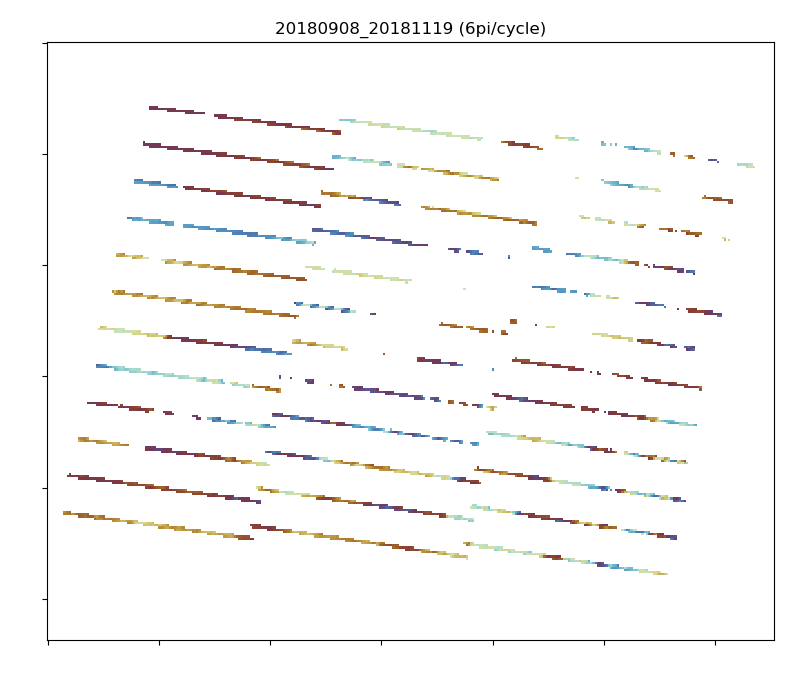

In [ ]:
# see one of the discarded ifgs:
! pwd
pair='20180908_20181119'
png = os.path.join('TS_GEOCml10GACOS','11bad_ifg_ras',pair+'.unw.png')
#png = os.path.join('GEOCml2GACOSclip',pair,pair+'.unw.png')
display(png)

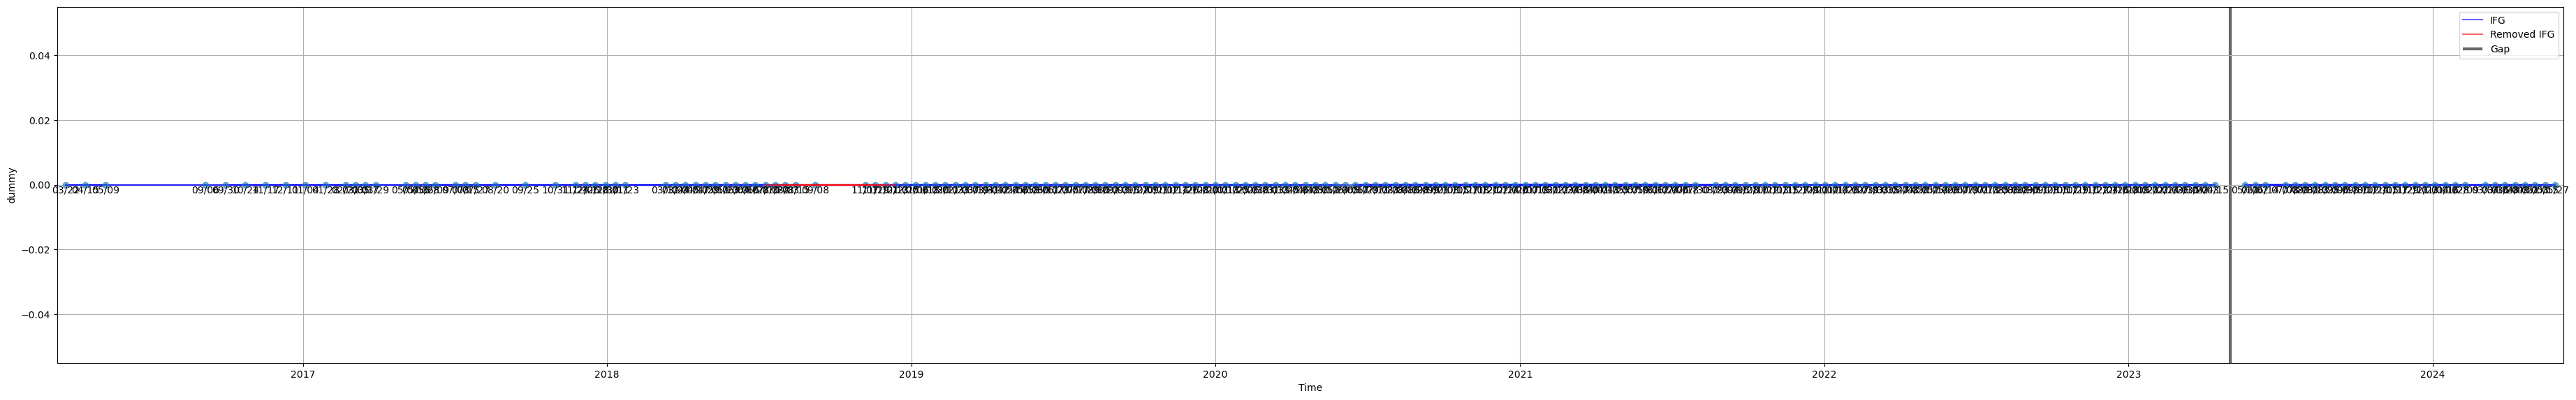

In [321]:
#check network
png='TS_GEOCml10GACOS/network/network11.png'
display(png)

# Step 1-2: Loop Closure

### LiCSBAS12_loop_closure.py
This script identifies bad unw by checking loop closures of interferometric triplets, i.e. non-zero residuals 
$$\phi_{123}=\phi_{12}+\phi_{23}-\phi_{13}$$


<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/20171203_20171215_20171227_loop.png" width="400">

This procedure runs 4 iterations where the following is applied, to investigate loop closure: 
1. iteration - identify loops and mark/not use unw ifgs of higher overall RMSE than given threshold, tolerating $2\pi$ phase jumps
2. iteration - check loop errors per pixel and select stable reference point (all valid unw data and a minimum of loop phase RMSE)
3. iteration - use reference area, do not tolerate $2\pi$ jumps, re-identify unw ifgs of higher overall RMSE than given threshold and remove them as bad
4. iteration - calculate statistics (n_loop_err, n_ifg_noloop) and (new update) nullify pixels of unws that only appear in non-closed loop -> good pixels of bad ifgs are still used  


**Note:** LiCSAR team works actively to update this procedure to possibly fix the unwrapping errors causing non-zero loop closures in connected components, rather than removing the whole interferogram or pixels (if using **--nullify**) affected by unclosed phase loops.

**cells \[ 12 \]**

In [ ]:
! LiCSBAS12_loop_closure.py -h
# e.g. LiCSBAS12_loop_closure.py -d GEOCml10GACOS -l 3 --n_para 1
printbold()


LiCSBAS12_loop_closure.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS12_loop_closure.py -h

v1.6.4 20230901 Lin Shen, COMET
v1.6.3 20220330 Milan Lazecky, COMET
v1.6.2 20211102 Milan Lazecky, COMET
v1.6.1 20210405 Yu Morishita, GSI

Overview
This script identifies bad unw by checking loop closure.
A preliminary reference point that has all valid unw data and the smallest RMS
of loop phases is also determined.

Input & output files
Inputs in GEOCml*/ :
 - yyyymmdd_yyyymmdd/
   - yyyymmdd_yyyymmdd.unw[.png]
   - yyyymmdd_yyyymmdd.cc
 - slc.mli.par
 - baselines (may be dummy)

Inputs in TS_GEOCml*/ :
 - info/11bad_ifg.txt  : List of bad ifgs identified in step11

Outputs in TS_GEOCml*/ :
 - 12loop/
   - loop_info.txt : Statistical information of loop phase closure
   - bad_ifg_*.txt : List of bad ifgs identified by loop closure
   - good_loop_png/*.png : png images of good loop phase closure
   - bad_loop_png/*.png  : png images of bad loop pha

In [316]:
print('running the command')
! LiCSBAS12_loop_closure.py -d GEOCml10GACOS -l 1.5 --nopngs --multi_prime --nullify
printbold()
# ETA 7 min., rerunning: ETA few seconds

running the command

LiCSBAS12_loop_closure.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS12_loop_closure.py -d GEOCml10GACOS -l 1.5 --nopngs --multi_prime --nullify

loop_thre : 1.5 rad

1st Loop closure check and make png for all possible 1161 loops,
with 8 parallel processing...
    0/1161th loop...
  200/1161th loop...
  100/1161th loop...
  300/1161th loop...
  500/1161th loop...
  400/1161th loop...
  600/1161th loop...
  800/1161th loop...
  700/1161th loop...
  1000/1161th loop...
  900/1161th loop...
  1100/1161th loop...

2nd Loop closure check without bad ifgs to define ref area...
with 8 parallel processing...
    0/1161th loop...
  300/1161th loop...
  600/1161th loop...
  700/1161th loop...
  900/1161th loop...
  200/1161th loop...
  500/1161th loop...
  400/1161th loop...
  100/1161th loop...
  1000/1161th loop...
  1100/1161th loop...
  800/1161th loop...
debug: using orig LiCSBAS approach for ref point selection

3rd loop clo

**cells \[ 13 \]**

In [ ]:
! pwd
! head -n 10 TS_GEOCml10GACOS/12loop/loop_info.txt
! echo "..."
! tail -n 30 TS_GEOCml10GACOS/12loop/loop_info.txt

/Users/rochelle/078D_05435_131313
# loop_thre: 1.5 rad
# *: Removed w/o ref, **: No ref, ***: Removed w/ ref
# /: Candidates of bad loops but causative ifgs unidentified
# image1   image2   image3 RMS w/oref  w/ref
20160322 20160415 20160509     3.42 *  --      
20160322 20160415 20160906     4.84 *  --      
20160906 20160930 20161024    19.63 *  --      
20160930 20161024 20161117     5.67 *  --      
20160930 20161024 20161211    14.41 *  --      
20160930 20161117 20161211     1.83 *  --      
...
20230708 20230801 20230825     0.34 /  0.34    
20230708 20230813 20230825     1.21 /  1.21    
20230720 20230801 20230813     3.85 *  --      
20230720 20230801 20230825     0.39    0.39    
20230720 20230801 20230906     0.38    0.38    
20230720 20230813 20230825     3.35 *  --      
20230720 20230813 20230906     2.71 *  --      
20230720 20230825 20230906     0.37    0.37    
20230801 20230813 20230825     0.96 /  0.96    
20230801 20230813 20230906     1.38 /  1.38    
20230801 2023

In [236]:
! ls TS_GEOCml10GACOS/12loop/bad_loop_png

ls: TS_GEOCml10GACOS/12loop/bad_loop_png: No such file or directory


In [ ]:
# see one of the triplets of discarded ifgs:
triplet = '20171226_20180101_20180113'
#triplet = '20171108 20171226 20180101' # example of bad loop
#triplet = '20161014 20161020 20161101' # example of candidate to bad loop that is used further
triplet = triplet.replace(' ','_')
png = os.path.join('TS_GEOCml2GACOSclip','12loop','bad_loop_png',triplet+'_loop.png')
if not os.path.exists(png):
    png = os.path.join('TS_GEOCml2GACOSclip','12loop','good_loop_png',triplet+'_loop.png')
print('Note: the figure below was generated during 1st iteration, i.e. before referencing/without multi-prime')
display(png)

Note: the figure below was generated during 1st iteration, i.e. before referencing/without multi-prime
This png file does not exist, recheck please


In [ ]:
# check also no loop ifgs:
! echo "There are "`ls TS_GEOCml10GACOS/12no_loop_ifg_ras | wc -l`" pairs identified as not forming a complete loop triplet"
! ls TS_GEOCml2GACOSclip/12no_loop_ifg_ras

There are  2 pairs identified as not forming a complete loop triplet
ls: TS_GEOCml2GACOSclip/12no_loop_ifg_ras: No such file or directory


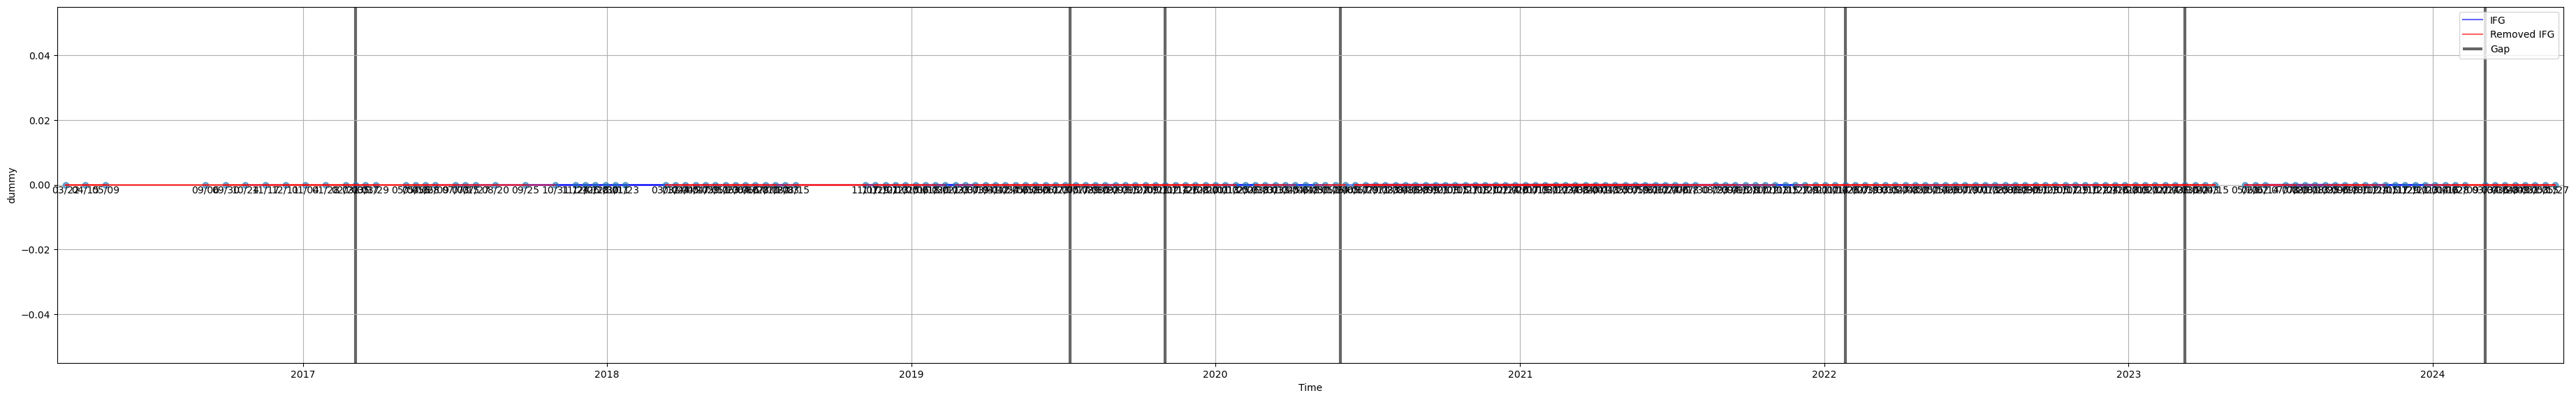

In [319]:
#check network
png='TS_GEOCml10GACOS/network/network12.png'
display(png)

# Step 1-3: Small Baseline Inversion

### LiCSBAS13_sb_inv.py
This script inverts the SB network of unw to obtain the time series and velocity using NSBAS ([López-Quiroz et al., 2009](https://www.sciencedirect.com/science/article/pii/S0926985109000251); [Doin et al., 2011](https://earth.esa.int/documents/10174/1573056/Presentation_small_baseline_NSBAS_Etna_deformation_Envisat.pdf)) approach.  
A stable reference point is determined after the inversion.  
RMS of the time series wrt median among all points is calculated for each point.  
Then the point with minimum RMS and minimum n_gap is selected as new stable reference point.

**cells \[ 14 \]**

In [ ]:
! LiCSBAS13_sb_inv.py -h 
# e.g. LiCSBAS13_sb_inv.py -d GEOCml10GACOS --n_para 1 --mem_size 1000
printbold()


LiCSBAS13_sb_inv.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS13_sb_inv.py -h


This script inverts the SB network of unw to obtain the time series and
velocity using NSBAS (López-Quiroz et al., 2009; Doin et al., 2011) approach.
A stable reference point is determined after the inversion. RMS of the time
series wrt median among all points is calculated for each point.
Then the point with minimum RMS and minimum n_gap is selected as new stable
reference point.

Input & output files
Inputs in GEOCml*/ :
 - yyyymmdd_yyyymmdd/
   - yyyymmdd_yyyymmdd.unw
   - yyyymmdd_yyyymmdd.cc
 - EQA.dem_par
 - slc.mli.par
 - baselines (may be dummy)
[- [ENU].geo]

Inputs in TS_GEOCml*/ :
 - info/
   - 11bad_ifg.txt
   - 12bad_ifg.txt
   - 12ref.txt
[-results/]
[  - coh_avg]
[  - hgt]
[  - n_loop_err]
[  - n_unw]
[  - slc.mli]

Outputs in TS_GEOCml*/ :
 - cum.h5             : Cumulative displacement (time-seires) in mm
 - results/
   - vel[.png]        : Velo

In [288]:
print('running the command')
! LiCSBAS13_sb_inv.py -d GEOCml10GACOS --singular

printbold()

running the command

LiCSBAS13_sb_inv.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS13_sb_inv.py -d GEOCml10GACOS --singular

In geographical coordinates

Not enough memory available compared to mem_size (8000 MB).
Reduce mem_size automatically to 1426 MB.
Read cum data on memory (fast but need memory).
Patch: 1
Patchrows:
[[0, 285]]

Size of image (w,l)    : 331, 285
# of all images        : 194
# of images to be used : 192
# of all ifgs          : 668
# of ifgs to be used   : 635
# of removed ifgs      : 33
Threshold of used unw  : 192

Reference area (X/Y)   : 206:207/145:146
Allowed memory size    : 1426 MB
Number of patches      : 1
Inversion algorism     : LS
Gamma value            : 0.0001
store_patches: True

Process 285/285th line (1/1th patch)...
  Reading 635 ifg's unw data...
  29741/94335 points removed due to not enough ifg data...

  Identifing gaps, and counting n_gap and n_ifg_noloop,
  with 8 parallel processing...
    Runni

LiCSBAS procedure will first invert matrix for points having all unwrapped values (no NaNs) using the full NSBAS set of equations (same result as for $\bf d = \bf G \bf m$ where $\bf d$ is set of unwrapped data related to $\bf m$ that is a vector of incremental displacements, through design matrix $\bf G$) and then runs for incomplete points to find $\bf m$, filling empty values under assumption that the displacement is linear in time, i.e. solving points with missing values using set of equations:
$$\bf d = \bf G \bf m$$ $$0 = 0.0001(B m - vt - c)$$

for details (e.g. definition of matrix B) see https://doi.org/10.3390/RS12030424  

In our case, using **--singular** approach, we simplify the calculation of the gaps (missing values) by using only the partial (p) range of SB-extracted cumulated increments (both cumulated displacement $ \sum m_p$ and time $ \sum t_p $ values), and only filling the gaps assuming constant linear velocity $$ \overline{v} = \frac{\sum m_p}{\sum t_p}. $$

This would normally lead to similar outputs through significantly simpler computation, yet it should be considered more prone to mistakes than if using least squares as in the standard LiCSBAS inversion.


**cells \[ 15 \]**

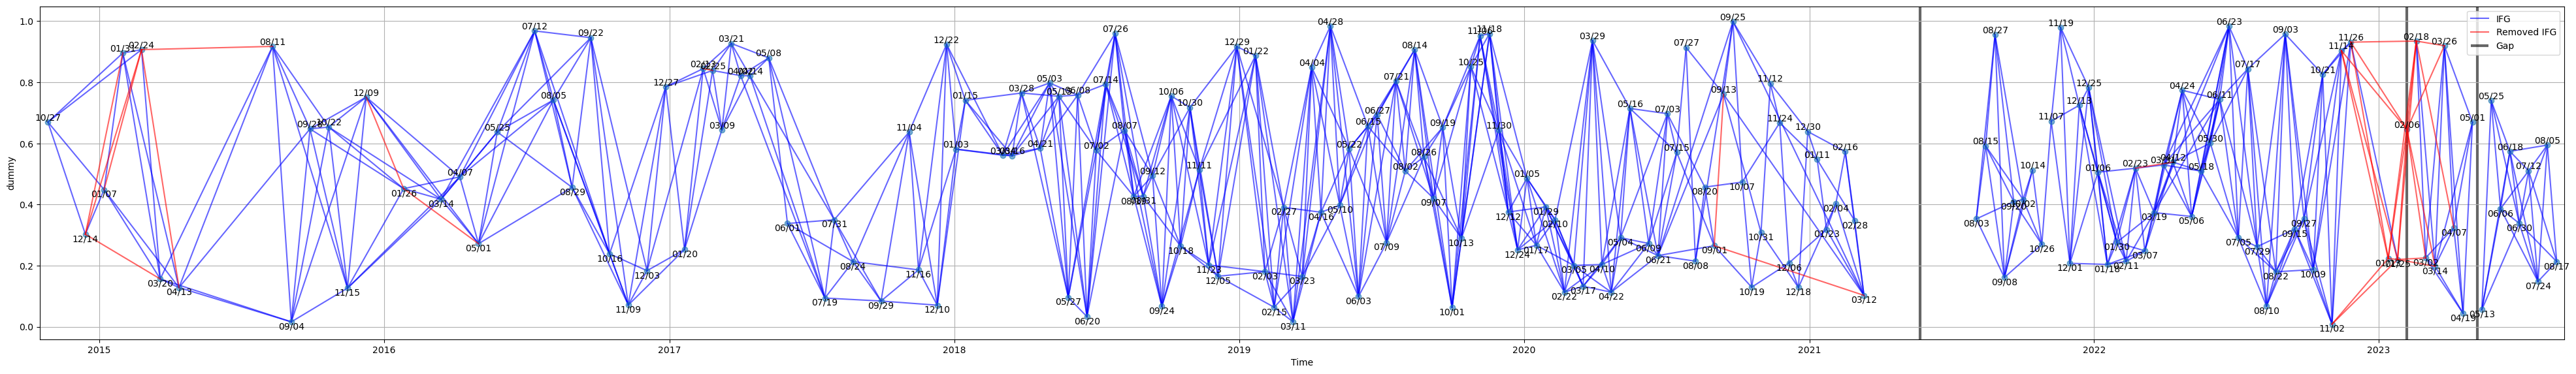

In [289]:
#check network
png='TS_GEOCml10GACOS/network/network13.png'
display(png)

TS_GEOCml10GACOS/results/coh_avg.png
TS_GEOCml10GACOS/results/coh_avg_12.png
TS_GEOCml10GACOS/results/loop_ph_avg_abs.png
TS_GEOCml10GACOS/results/mask.png
TS_GEOCml10GACOS/results/maxTlen.png
TS_GEOCml10GACOS/results/n_gap.png
TS_GEOCml10GACOS/results/n_ifg_noloop.png
TS_GEOCml10GACOS/results/n_loop_err.png
TS_GEOCml10GACOS/results/n_loop_err_rat.png
TS_GEOCml10GACOS/results/n_nullify.png
TS_GEOCml10GACOS/results/n_nullify_rat.png
TS_GEOCml10GACOS/results/n_unw.png
TS_GEOCml10GACOS/results/resid_rms.png
TS_GEOCml10GACOS/results/stc.png
TS_GEOCml10GACOS/results/vel.filt.mskd.png
TS_GEOCml10GACOS/results/vel.filt.png
TS_GEOCml10GACOS/results/vel.mskd.png
TS_GEOCml10GACOS/results/vel.png
TS_GEOCml10GACOS/results/vintercept.filt.mskd.png
TS_GEOCml10GACOS/results/vintercept.filt.png
TS_GEOCml10GACOS/results/vintercept.png
TS_GEOCml10GACOS/results/vstd.png


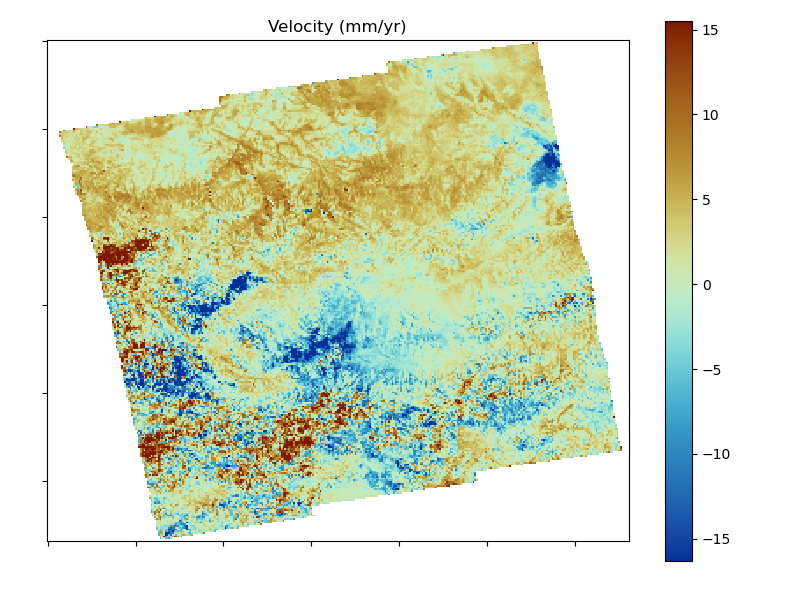

In [290]:
! ls TS*/results/*.png
png='TS_GEOCml10GACOS/results/vel.png'
display(png)

# Step 1-4: Calculate STD of Velocity by Bootstrap

### LiCSBAS14_vel_std.py
This script calculates the standard deviation of the velocity by the bootstrap method and STC (spatio-temporal consistency; [Hanssen et al., 2008](https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/documents/Hanssen_2008.pdf)).

**Note:** LiCSAR team actively develops the LiCSBAS routines. Current release includes optional re-estimate of velocity with outlier detection/removal.

**cells \[ 16 \]**

In [ ]:
! LiCSBAS14_vel_std.py -h
# e.g. LiCSBAS14_vel_std.py -t TS_GEOCml10GACOS
printbold()


LiCSBAS14_vel_std.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS14_vel_std.py -h


Overview
This script calculates the standard deviation of the velocity by the bootstrap method and STC (spatio-temporal consistency; Hanssen et al., 2008).
Optionally, it can improve velocity estimates using RANSAC algorithm
Input & output files
Inputs in TS_GEOCml*/ :
 - cum.h5 : Cumulative displacement (time-series) in mm

Outputs in TS_GEOCml*/results/ :
 - vstd[.png] : Std of velocity in mm/yr
 - stc[.png]  : Spatio-temporal consistency in mm
 [- vel2[.png], intercept2: Velocity and intercept after RANSAC outlier-free regression]

=====
Usage
=====
LiCSBAS14_vel_std.py -t tsadir [-i cumfile] [--mem_size float] [--gpu] [--ransac]

 -t  Path to the TS_GEOCml* dir.
 -i  Path to cum file (Default: cum.h5)
 --mem_size   Max memory size for each patch in MB. (Default: 4000)
 --gpu        Use GPU (Need cupy module)
 --ransac     Recalculate velocity free from out

In [291]:
print('running the command')
! LiCSBAS14_vel_std.py -t TS_GEOCml10GACOS --mem_size 1000
# ETA 5 sec
printbold()

running the command

LiCSBAS14_vel_std.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS14_vel_std.py -t TS_GEOCml10GACOS --mem_size 1000

Process 285/285th line (1/1th patch)...
  Calculating STC...
  29741/94335 points removed due to no data...
  Calculating std of velocity by bootstrap...
  Running 100/100th bootstrap...
  Elapsed time for 1th patch: 13 sec

Output png images...

Elapsed time: 00h 00m 13s

LiCSBAS14_vel_std.py Successfully finished!!

Output directory: TS_GEOCml10GACOS

done


**cells \[ 17 \]**

ls: -alh: No such file or directory
TS_GEOCml10GACOS/results/coh_avg.png
TS_GEOCml10GACOS/results/coh_avg_12.png
TS_GEOCml10GACOS/results/loop_ph_avg_abs.png
TS_GEOCml10GACOS/results/maxTlen.png
TS_GEOCml10GACOS/results/n_gap.png
TS_GEOCml10GACOS/results/n_ifg_noloop.png
TS_GEOCml10GACOS/results/n_loop_err.png
TS_GEOCml10GACOS/results/n_loop_err_rat.png
TS_GEOCml10GACOS/results/n_nullify.png
TS_GEOCml10GACOS/results/n_nullify_rat.png
TS_GEOCml10GACOS/results/n_unw.png
TS_GEOCml10GACOS/results/resid_rms.png
TS_GEOCml10GACOS/results/stc.png
TS_GEOCml10GACOS/results/vel.png
TS_GEOCml10GACOS/results/vintercept.png
TS_GEOCml10GACOS/results/vstd.png


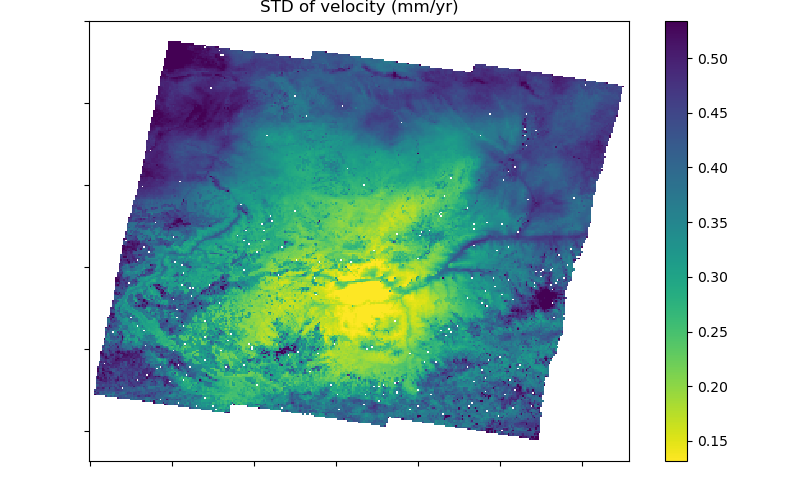

In [256]:
! ls TS*/results/*.png -alh
png='TS_GEOCml10GACOS/results/vstd.png'
display(png)

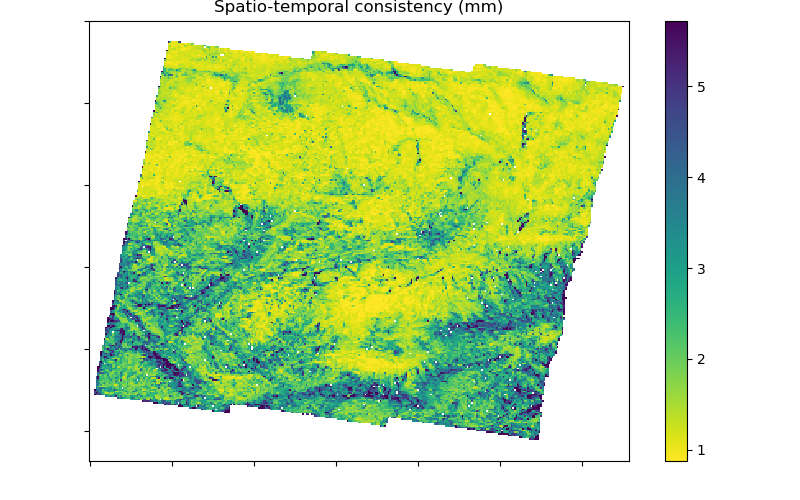

In [257]:
png='TS_GEOCml10GACOS/results/stc.png'
display(png)

# Step 1-5: Mask Time Series

### LiCSBAS15_mask_ts.py

This script makes a mask for time series using several noise indices.  
The pixel is masked if any of the values of the noise indices for a pixel is worse (larger or smaller) than a specified threshold.  

<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/mask_ts.png" width="900">

| Noise index | Meaning |
| --- | ----------- |
| coh_avg | Average value of the interferometric coherence across the stack (0–1) |
| n_unw | Number of unwrapped data used in the time series calculation (as a ratio to the number of images; i.e., if 1.5, n_unw=1.5*n_im) |
| vstd | Standard deviation of the velocity (mm/yr) estimated in Step 1-4 |
| maxTlen | Maximum time length of the connected network (years). The larger the value, the better the precision in the velocity estimate. |
| n_gap | Number of gaps in the interferogram network and time series breaks. |
| stc | Spatio-temporal consistency (mm) (Hanssen et al., 2008), estimated in Step 1-4. |
| n_ifg_noloop | Number of interferograms with no loops that cannot be checked by the loop closure and possibly have unidentified unwrapping errors. |
| n_loop_err | Number of the unclosed loops after the network refinement in Step 1-2. |
| resid_rms | RMS of residuals in the small baseline (SB) inversion (mm). |

In [141]:
# check the contents of the folder
frame = '144A_05476_141414'
framedir = os.path.join(os.environ['HOME'],frame)
# framedir = os.path.join(os.environ['HOME'],frame + "_test_reunwrapping")
os.chdir(framedir)

! pwd
! ls


/Users/rochelle/144A_05476_141414
GACOS            GEOCml10GACOS    batch_LiCSBAS.sh
GEOC             TS_GEOCml10GACOS


**cells \[ 18 \]**

In [ ]:
! LiCSBAS15_mask_ts.py -h
# e.g. LiCSBAS15_mask_ts.py -t TS_GEOCml10GACOS -c 0.05 -u 1.5 -v 100 -T 1 -g 10 -s 5  -i 50 -l 5 -r 2
printbold()


LiCSBAS15_mask_ts.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS15_mask_ts.py -h


Overview
This script makes a mask for time series using several noise indices. The pixel is masked if any of the values of the noise indices for a pixel is worse (larger or smaller) than a specified threshold.

Input & output files
Inputs in TS_GEOCml*/ :
 - results/[vel, coh_avg, n_unw, vstd, maxTlen, n_gap, stc,
            n_ifg_noloop, n_loop_err, resid_rms, n_nullify
            coh_avg_XX, n_loop_err_rat]
 - info/13parameters.txt
 
Outputs in TS_GEOCml*/
 - mask_ts[_mskd].png : Quick-look image of mask and noise indices
 - results/
   - vel.mskd[.png]   : Masked velocity
   - mask[.png]       : Mask
 - info/15parameters.txt : List of used parameters

=====
Usage
=====
LiCSBAS15_mask_ts.py -t tsadir [-c coh_thre] [-u n_unw_r_thre] [-v vstd_thre]
  [-T maxTlen_thre] [-g n_gap_thre] [-s stc_thre] [-i n_ifg_noloop_thre]
  [-l n_loop_err_thre] [-r resid_rms_t

/Users/rochelle/144A_05476_141414_test_singular
running the command

LiCSBAS15_mask_ts.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS15_mask_ts.py -t TS_GEOCml10GACOS -c 0.12 -v 40 -u 1.5 -T 1 -g 30 -s 10 -i 1000 -L 0.4 -r 4 --avg_phase_bias 0.4
Using loop_ph_avg_abs parameter instead of n_loop_err

Noise index    : Threshold  (rate to be masked)
- coh_avg      : 0.12       ( 0.0%)
- n_unw        :  291       ( 0.1%)
- vstd         : 40.0 mm/yr ( 0.0%)
- maxTlen      :  1.0 yr    ( 0.6%)
- n_gap        :   30       ( 1.5%)
- stc          : 10.0 mm    ( 0.1%)
- n_ifg_noloop : 1000       ( 0.0%)
- loop_ph_avg_abs :  0.4 rad   ( 1.1%)
- resid_rms    :  4.0 mm    ( 0.6%)

Masked pixels  : 2035/64593 (3.2%)
Kept pixels    : 62558/64593 (96.8%)


Elapsed time: 00h 00m 01s

LiCSBAS15_mask_ts.py Successfully finished!!

Output png: TS_GEOCml10GACOS/mask_ts.png

done


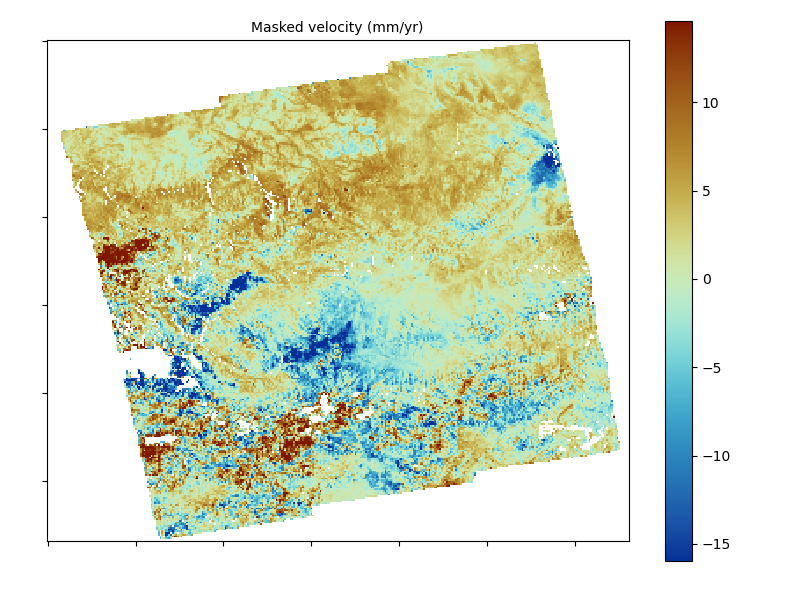

In [294]:
! pwd
print('running the command')
! LiCSBAS15_mask_ts.py -t TS_GEOCml10GACOS -c 0.12 -v 40 -u 1.5 -T 1 -g 30 -s 10 -i 1000 -L 0.4 -r 4  --avg_phase_bias 0.4
printbold()
png = 'TS_GEOCml10GACOS/results/vel.mskd.png'
display(png)

/Users/rochelle/144A_05476_141414_test_singular


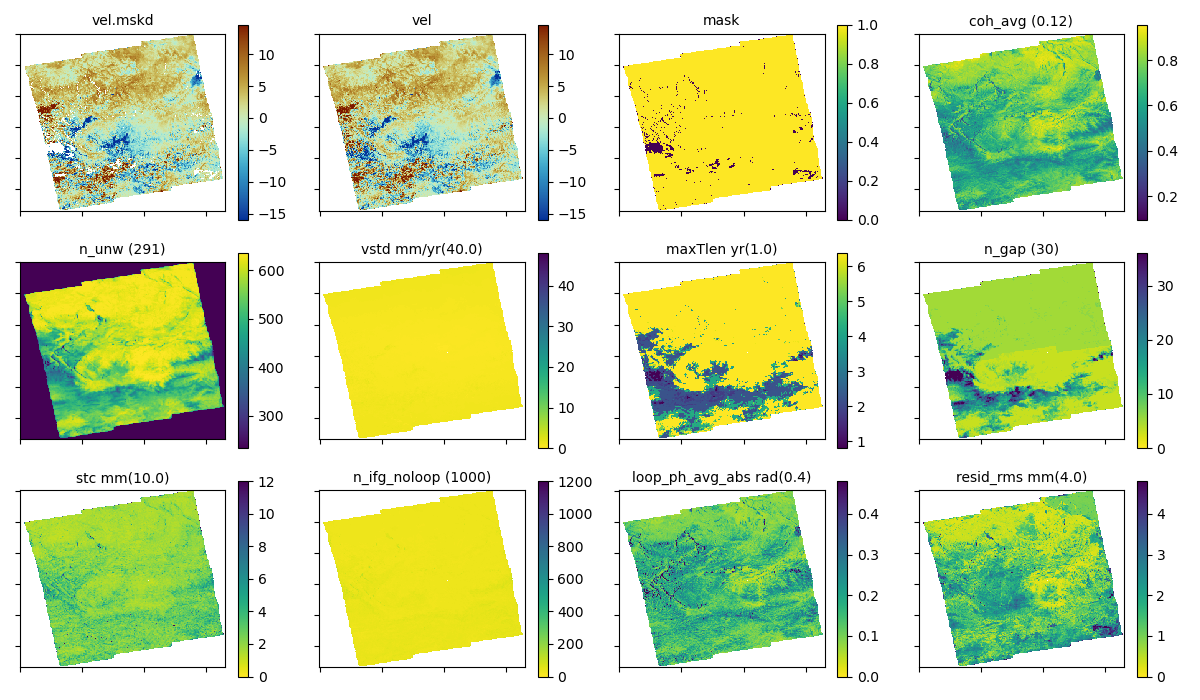

In [295]:
! pwd
png = 'TS_GEOCml10GACOS/mask_ts.png'
display(png)

In [ ]:
print('running the command')
! LiCSBAS15_mask_ts.py -t TS_GEOCml2GACOSclip -i 70 -l 10 -r 2
# ETA 2 sec
printbold()
png = 'TS_GEOCml2GACOSclip/results/vel.mskd.png'
display(png)

**cell \[ 19 \]**

In [ ]:
png = 'TS_GEOCml2GACOSclip/mask_ts.png'
display(png)

# Step 1-6: Filter (& Deramp) Time Series

### LiCSBAS16_filt_ts.py
This script applies spatio-temporal filter (HP in time and LP in space with gaussian kernel, same as StaMPS) to the time series of displacement.  
Deramping (1D, bilinear, or 2D polynomial) can also be applied if -r option is used.  
Topography-correlated components (linear with elevation) can also be subtracted with --hgt_linear option simultaneously with deramping before spatio-temporal filtering.  
The impact of filtering (deramp and linear elevation as well) can be visually checked by showing 16filt\*/\*png.  
A stable reference point is determined after the filtering as well as Step 1-3.  

### Previews:
Deramping:  
<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/20180102_deramp.png" width="600">  

Removing phase correlated to topography:  
<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/20180102_hgt_linear.png" width="600">  
<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/20180102_hgt_corr.png" width="400">  

Spatio-temporal filtering:  
<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/20180102_filt.png" width="600">

**cells \[ 20 \]**

In [ ]:
! LiCSBAS16_filt_ts.py -h
# e.g. LiCSBAS16_filt_ts.py -t TS_GEOCml2GACOSclip -r 2 --n_para 1
printbold()


LiCSBAS16_filt_ts.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS16_filt_ts.py -h


This script applies spatio-temporal filter (HP in time and LP in space with gaussian kernel, same as StaMPS) to the time series of displacement. Deramping (1D, bilinear, or 2D polynomial) can also be applied if -r option is used. Topography-correlated components (linear with elevation) can also be subtracted with --hgt_linear option simultaneously with deramping before spatio-temporal filtering. The impact of filtering (deramp and linear elevation as well) can be visually checked by showing 16filt*/*png. A stable reference point is determined after the filtering as well as Step 1-3.

Input & output files
Inputs in TS_GEOCml*/ :
 - cum.h5
 - results
   - mask
   - hgt (if --hgt_linear option is used)
   [- U (if --hgt_linear option is used)]
 - info/13parameters.txt

Outputs in TS_GEOCml*/ :
 - cum_filt.h5
 - 16filt_cum/
   - yyyymmdd_filt.png
  [- yyyymmdd_der

In [296]:
print('running the command')
! LiCSBAS16_filt_ts.py -t TS_GEOCml10GACOS --n_para 8 --hgt_linear  -r 1 #--nofilter
# ETA (on typical local computer): 10 min. with hgt_linear, 7 minutes without
# Binder: >20 minutes if using spatio-temporal filter -> here we only deramp and use hgt_linear
printbold()

running the command

LiCSBAS16_filt_ts.py ver1.14.2 (dev) 2023-06-28 Dr. Yu Morishita and COMET dev team (ML,QO,JM,LS,..)
LiCSBAS16_filt_ts.py -t TS_GEOCml10GACOS --n_para 8 --hgt_linear -r 1
No bperp field found in cum.h5. Skip.
scaling by incidence angle
/Users/rochelle/Documents/GitHub/LiCSBAS/bin/LiCSBAS16_filt_ts.py:351: RuntimeWarning: divide by zero encountered in divide
  hgt = hgt / cosinc
/Users/rochelle/Documents/GitHub/LiCSBAS/bin/LiCSBAS16_filt_ts.py:351: RuntimeWarning: invalid value encountered in divide
  hgt = hgt / cosinc

Size of image (w,l)      : 331, 285
Number of images         : 192
Width of filter in space : 2 km (2.2x1.8 pixel)
Width of filter in time  : 0.138 yr (50 days)
Deramp flag              : 1
hgt-linear flag          : True
Minimum hgt              : 200 m
Maximum hgt              : 10000 m

Deramp ifgs with the degree of 1 and hgt-linear,
with 8 parallel processing...
    0/192th image...
   30/192th image...
/Users/rochelle/Documents/GitHub/LiCSBAS/

**cells \[ 21 \]**

In [ ]:
print('first 30 files of filtered dataset')
! ls TS_GEOCml10GACOS/16filt_cum | head -n 30

first 30 files of filtered dataset
20160309_filt.png
20160309_hgt_corr.png
20160309_hgt_linear.png
20160402_filt.png
20160402_hgt_corr.png
20160402_hgt_linear.png
20160426_filt.png
20160426_hgt_corr.png
20160426_hgt_linear.png
20160520_filt.png
20160520_hgt_corr.png
20160520_hgt_linear.png
20160613_filt.png
20160613_hgt_corr.png
20160613_hgt_linear.png
20160707_filt.png
20160707_hgt_corr.png
20160707_hgt_linear.png
20160731_filt.png
20160731_hgt_corr.png
20160731_hgt_linear.png
20160824_filt.png
20160824_hgt_corr.png
20160824_hgt_linear.png
20160917_filt.png
20160917_hgt_corr.png
20160917_hgt_linear.png
20161011_filt.png
20161011_hgt_corr.png
20161011_hgt_linear.png


In [ ]:
#epoch = '20161026'
epoch = '20200229'

In [ ]:
print('effect of deramping:')
png='TS_GEOCml10GACOS/16filt_cum/{}_deramp.png'.format(epoch)
display(png)

effect of deramping:
This png file does not exist, recheck please


effect of removing linear correlation to height:
colour scale: 6pi/cycle


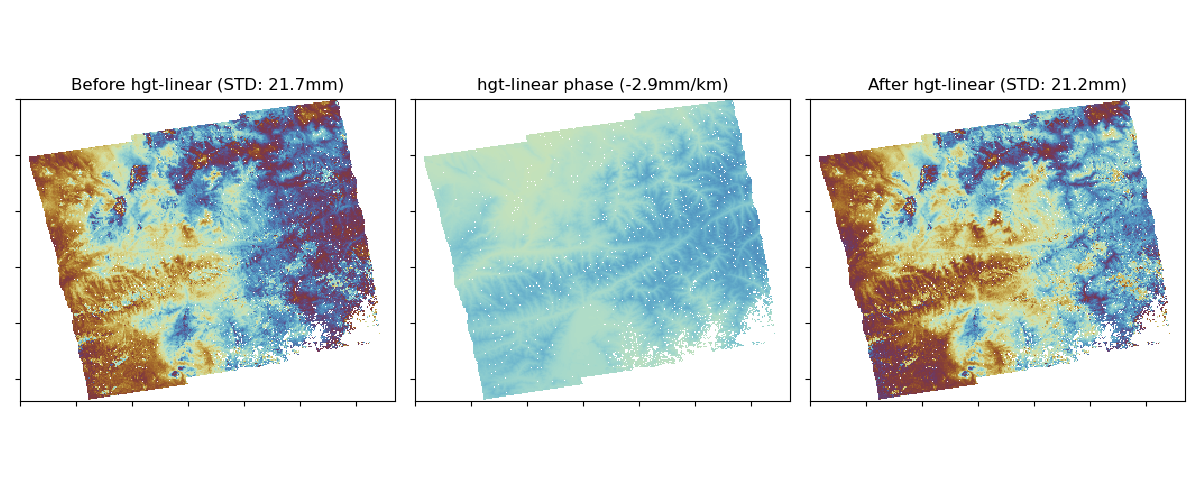

In [ ]:
print('effect of removing linear correlation to height:')
print('colour scale: 6pi/cycle')
png='TS_GEOCml10GACOS/16filt_cum/{}_hgt_linear.png'.format(epoch)
display(png)

correlation to height


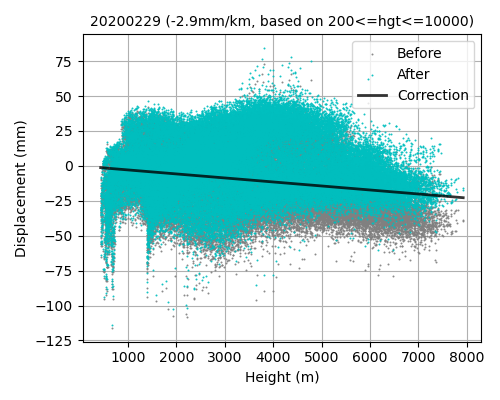

In [ ]:
print('correlation to height')
png='TS_GEOCml10GACOS/16filt_cum/{}_hgt_corr.png'.format(epoch)
display(png)

In [ ]:
print('Note: we have avoided spatio-temporal filter using --nofilter option. If run, you would see results here:')
print('effect of spatio-temporal filter:')
png='TS_GEOCml2GACOSclip/16filt_cum/{}_filt.png'.format(epoch)
display(png)

# Viewing the final time series

**cells \[ 22 \]**

The original LiCSBAS script offers advanced visualisation of various output parameters, allows for re-referencing the data etc.

In [ ]:
! LiCSBAS_plot_ts.py -h
LiCSBAS_plot_ts.py -i TS_GEOCml10GACOS/cum_filt.h5
# e.g. LiCSBAS_plot_ts.py -i TS_GEOCml2GACOSclip/cum_filt.h5


LiCSBAS_plot_ts.py ver1.13.4 20210910 Y. Morishita
LiCSBAS_plot_ts.py -h

v1.13.4 20210910 Yu Morishita, GSI

Overview
This script displays the velocity, cumulative displacement, and noise indices,
and plots the time series of displacement. You can interactively change the
displayed image/area and select a point for the time series plot. The reference
area can also be changed by right dragging.

Inputs
 - cum_filt.h5 and/or cum.h5
[- mask, coh_avg, n_unw, vstd, n_gap, n_ifg_noloop, n_loop_err, resid_rms,
   maxTlen, stc, scl.mli, hgt in results dir]

=====
Usage
=====
LiCSBAS_plot_ts.py [-i cum[_filt].h5] [--i2 cum*.h5] [-m yyyymmdd] [-d results_dir]
    [-u U.geo] [-r x1:x2/y1:y2] [--ref_geo lon1/lon2/lat1/lat2] [-p x/y]
    [--p_geo lon/lat] [-c cmap] [--nomask] [--vmin float] [--vmax float]
    [--auto_crange float] [--dmin float] [--dmax float] [--ylen float]
    [--ts_png pngfile]

 -i    Input cum hdf5 file (Default: ./cum_filt.h5 or ./cum.h5)
 --i2  Input 2nd cum hdf5 file
    

<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/sample_vel.png" width="550"> <img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/sample_ts.png" width="500">

In [ ]:
print('see the static example of the viewer')
%run ../bin/LiCSBAS_plot_ts.py -i TS_GEOCml2GACOSclip/cum.h5 -p 53/39
# %run ../bin/LiCSBAS_plot_ts.py -i TS_GEOCml2GACOSclip/cum_filt.h5 -p 53/39

In [ ]:
print('use the viewer to see filtered (deramped) dataset - note the time series lines')
%run ../bin/LiCSBAS_plot_ts.py -i TS_GEOCml2GACOSclip/cum_filt.h5 -p 53/39

In [ ]:
print('generating png file of time series for given coordinates')
#! LiCSBAS_plot_ts.py -i TS_GEOCml2GACOSclip/cum.h5 --ts_png test_ts.png -p 53/39 >/dev/null
! LiCSBAS_plot_ts.py -i TS_GEOCml2GACOSclip/cum_filt.h5 --ts_png test_ts.png -p 53/39 >/dev/null
display('test_ts.png')

It is, however, convenient to transform the output data to a standard NetCDF in geographic coordinates, so we can use any standard program for further processing, e.g. in GIS.

These optional scripts will export the results to a standard GeoTIFF file or a NetCDF datacube that you may use both in any GIS environment, or e.g. to load to python via xarray etc.

For more information (and example on QGIS Time Series viewer) see [LiCSBAS wiki](https://github.com/yumorishita/LiCSBAS/wiki/4_other_tools) 

In [116]:
# to export velocities to a geotiff
# ! LiCSBAS_flt2geotiff.py -h

frame = '078D_05435_131313'
framedir = os.path.join(os.environ['HOME'],frame)
# framedir = os.path.join(os.environ['HOME'],frame + "_test_reunwrapping")
os.chdir(framedir)

! pwd
! ls

/Users/rochelle/078D_05435_131313
078D_05435_131313.E.tif
078D_05435_131313.N.tif
078D_05435_131313_deramp.vel.filt.mskd.geo.tif
GACOS
GEOC
GEOC.MLI
GEOCml10
GEOCml10GACOS
TS_GEOCml10GACOS
batch_LiCSBAS.sh
ifg_list.txt
log


In [112]:
! LiCSBAS_flt2geotiff.py -h


LiCSBAS_flt2geotiff.py ver1.5.1 20210209 Y. Morishita
LiCSBAS_flt2geotiff.py -h

v1.5.1 20210209 Yu Morishita, GSI

Overview
This script makes a GeoTIFF file from an image file (only in float32 format). The geotiff file can be read by a GIS software (e.g., QGIS) and used to make a figure. Nan will be regarded as NoDataValue as default. 0 can be replaced with nan.

=====
Usage
=====
LiCSBAS_flt2geotiff.py -i infile -p dempar [-o outfile] [--zero2nan] [--nan2zero] [--a_nodata num] [--bigendian]

 -i  Path to input file (float, little endian)
 -p  Path to dem parameter file (EQA.dem_par)
 -o  Output geotiff file (Default: infile[.geo].tif)
 --a_nodata   Assign a specified nodata value in output (Default: nan)
              "None" assigns no value as nodata
 --zero2nan   Replace 0 with nan (Default: NOT replace 0 with nan)
 --nan2zero   Replace nan with 0 (Default: NOT replace nan with 0)
 --bigendian  If input file is in big endian




In [286]:
# ! LiCSBAS_flt2geotiff.py -i TS_GEOCml10GACOS/results/vel.filt.mskd -p GEOCml10GACOS/EQA.dem_par -o 144A_05476_141414.vel.filt.mskd.geo.tif
# ! LiCSBAS_flt2geotiff.py -i GEOCml10GACOS/N -p GEOCml10GACOS/EQA.dem_par -o  144A_05476_141414.N.tif
! LiCSBAS_flt2geotiff.py -i GEOCml10GACOS/E -p GEOCml10GACOS/EQA.dem_par -o  144A_05476_141414.E.tif


LiCSBAS_flt2geotiff.py ver1.5.1 20210209 Y. Morishita
LiCSBAS_flt2geotiff.py -i GEOCml10GACOS/E -p GEOCml10GACOS/EQA.dem_par -o 144A_05476_141414.E.tif
Use gdal module
/opt/anaconda3/envs/licsbas/lib/python3.12/site-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(

Elapsed time: 00h 00m 00s

LiCSBAS_flt2geotiff.py Successfully finished!!

Output: 144A_05476_141414.E.tif



In [ ]:
# to export all relevant data to a NetCDF datacube
! LiCSBAS_out2nc.py -h
# e.g. LiCSBAS_out2nc.py -i TS_GEOCml2*/cum.h5 -o 022D_04826_121209.nc


Let's export LiCSBAS output to the standard NetCDF datacube, and then view it through jupyter notebook. You may also download the NetCDF file and load into QGIS, ncview etc. etc.

In [115]:
! LiCSBAS_out2nc.py -h


LiCSBAS_out2nc.py ver1.05 20240420 M.Lazecky
LiCSBAS_out2nc.py -h

v1.05 20240420 Milan Lazecky, Leeds Uni

Overview
This script outputs a standard NetCDF4 file using LiCSBAS results


=====
Usage
=====
LiCSBAS_out2nc.py [-i infile] [-o outfile] [-m yyyymmdd]
     [--ref_geo lon1/lon2/lat1/lat2] [--clip_geo lon1/lon2/lat1/lat2]

 -i  Path to input cum file (Default: cum_filt.h5)
 -o  Output netCDF4 file (Default: output.nc)
 -m  Master (reference) date (Default: first date) - TODO: bperps are fixed-referred to the 1st date
 --ref_geo  Reference area in geographical coordinates as: lon1/lon2/lat1/lat2
 --clip_geo  Area to clip in geographical coordinates as: lon1/lon2/lat1/lat2
 --compress, -C  use zlib compression (very small files but time series may take long to load in GIS)
 --postfilter will interpolate VEL only through empty areas and filter in space
 --apply_mask  Will apply mask to all relevant variables
 



In [159]:

! pwd
! ls
! LiCSBAS_out2nc.py -i TS_GEOCml10GACOS/cum.h5 -o 144A_05476_141414_test1.nc

/Users/rochelle/144A_05476_141414
GACOS            GEOCml10GACOS    batch_LiCSBAS.sh
GEOC             TS_GEOCml10GACOS

LiCSBAS_out2nc.py ver1.05 20240420 M.Lazecky
LiCSBAS_out2nc.py -i TS_GEOCml10GACOS/cum.h5 -o 144A_05476_141414_test1.nc
some error loading bperp info


Elapsed time: 00h 00m 01s

LiCSBAS_out2nc.py Successfully finished!!

Output: 144A_05476_141414_test1.nc



In [ ]:
# loading the netcdf as xarray dataset
import xarray as xr
ncfile='022D_04826_121209.nc'
nc=xr.open_dataset(ncfile)

# explore the contents
nc

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
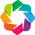

In [238]:
# run the preview through jupyter notebook - load necessary modules
import geoviews as gv
import holoviews as hv
import numpy as np
import geoviews.feature as gf
from geoviews import opts, tile_sources as gvts
from cartopy import crs
import panel as pn
from holoviews import streams
from matplotlib.figure import Figure
gv.extension('bokeh', 'matplotlib')
gv.output(size=200)

In [253]:
# prepare the previewer dataset

# get only velocity to show in map
vel = gv.Image(nc['vel'], ['lon','lat'])
themap = vel.opts(cmap='RdBu_r', colorbar=True, backend='bokeh')


# make a function that displays info at selected point
def showvel(x, y):
    try:
        selvel=np.float32(nc.vel.sel(lat=y, lon=x, method='nearest'))
        selcoh=np.float32(nc.coh.sel(lat=y, lon=x, method='nearest'))
    except:
        selvel=0
        selcoh=0
    return pn.pane.Str('velocity: %0.2f' %selvel +' mm/year, avg_coh:  %0.2f' %selcoh,width=300)



# Time series viewer function

# add layer to register taps (selected point)
tap = streams.SingleTap(transient=True)

def do_tap(x,y):
    return hv.Points([(x,y)])

taps_dmap = hv.DynamicMap(do_tap, streams=[tap])
taps_dmap.opts(color='black', size=5) #, tools=['hover'])


## set limits to time series
## ylims = (nc.cum.quantile(0.005),nc.cum.quantile(0.995))
ylims = (nc.cum.min(),nc.cum.max())
def plotts(x, y):
    try:
        selts=nc.sel(lat=y, lon=x, method='nearest').cum
        times=selts.time.values
        vals=selts.values
        fig = Figure(figsize=(4, 4))
        ax = fig.add_subplot(111)
        ax.set_title('line-of-sight displacement towards satellite')
        ax.set_ylabel('mm')
        ax.set_ylim(ylims)
        ax.grid('on')
        cf=ax.scatter(times,vals)
        return pn.pane.Matplotlib(fig)
    except:
        return pn.pane.Str('click to the map to show time series')


# add interactive transparency slider
opacity_slider = pn.widgets.FloatSlider(start=0, end=1, value=0.5, name='Opacity') #, throttled=True)

@pn.depends(alpha=opacity_slider)
def viewmap(alpha):
    fullmap = gvts.EsriImagery * gvts.OSM.apply.opts(alpha=0.5) * themap.apply.opts(alpha=alpha)*  taps_dmap  # not working on binder: gvts.StamenTerrainRetina * taps_dmap
    return fullmap

# set the click events (tapping) and run the layout
stream = hv.streams.Tap(source=themap, x=np.nan, y=np.nan)
layout = pn.Row(pn.Column(opacity_slider, viewmap),
                pn.Column(pn.bind(showvel, x=stream.param.x, y=stream.param.y),
                          pn.bind(plotts, x=stream.param.x, y=stream.param.y))
               )


layout

Row
    [0] Column
        [0] FloatSlider(name='Opacity', value=0.9)
        [1] ParamFunction(function)
    [1] Column
        [0] ParamFunction(function)
        [1] ParamFunction(function)

## Citations

Morishita, Y.; Lazecky, M.; Wright, T.J.; Weiss, J.R.; Elliott, J.R.; Hooper, A. LiCSBAS: An Open-Source InSAR Time Series Analysis Package Integrated with the LiCSAR Automated Sentinel-1 InSAR Processor. *Remote Sens.* **2020**, *12*, 424, https://doi.org/10.3390/RS12030424.

Morishita, Y.: Nationwide urban ground deformation monitoring in Japan using Sentinel-1 LiCSAR products and LiCSBAS. *Prog. Earth Planet. Sci.* **2021**, *8*, 6,  https://doi.org/10.1186/s40645-020-00402-7.

Lazecký, M.; Spaans, K.; González, P.J.; Maghsoudi, Y.; Morishita, Y.; Albino, F.; Elliott, J.; Greenall, N.; Hatton, E.; Hooper, A.; Juncu, D.; McDougall, A.; Walters, R.J.; Watson, C.S.; Weiss, J.R.; Wright, T.J. LiCSAR: An Automatic InSAR Tool for Measuring and Monitoring Tectonic and Volcanic Activity. *Remote Sens.* **2020**, *12*, 2430, https://doi.org/10.3390/rs12152430.

## Acknowledgements

The core and main functionality of LiCSBAS has been accomplished by Dr. Yu Morishita (Geospatial Information Authority of Japan) during his visit at the University of Leeds, funded by JSPS Overseas Research Fellowship (June 2018-March 2020). LiCSBAS is further developed by the team at the University of Leeds, under the supervision of Prof. Andy Hooper and Prof. Tim Wright.  

COMET is the UK Natural Environment Research Council's Centre for the Observation and Modelling of Earthquakes, Volcanoes and Tectonics. LiCSAR is developed as part of the NERC large grant, "Looking inside the continents from Space" (NE/K010867/1). LiCSAR contains modified Copernicus Sentinel-1 data analysed by the COMET. LiCSAR uses [JASMIN](http://jasmin.ac.uk), the UK’s collaborative data analysis environment.  

The [Scientific Colour Maps](http://www.fabiocrameri.ch/colourmaps.php) ([Crameri, 2018](https://doi.org/10.5194/gmd-11-2541-2018)) is used in LiCSBAS.


[<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/COMET_logo.png"  width="100">](https://comet.nerc.ac.uk/)   [<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/logo-leeds.png"  width="100">](https://environment.leeds.ac.uk/see/)  [<img src="https://raw.githubusercontent.com/wiki/yumorishita/LiCSBAS/images/LiCS_logo.jpg"  width="100">](https://comet.nerc.ac.uk/COMET-LiCS-portal/) 